In [ ]:
import warnings
warnings.filterwarnings(action='ignore')

!pip install google-play-scraper demoji nltk wordcloud matplotlib Levenshtein
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git


import json
import re
import string
import demoji
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google_play_scraper import Sort, reviews
from mpstemmer import MPStemmer
from nltk.corpus import stopwords

nltk.download('stopwords')

  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-rswbehsc
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-rswbehsc
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993335 sha256=b5063069a62101c302d11ec5f17185ef773a13abdcce55066ac86df27eae1db0
  Stored in directory: /root/.cache/pip/wheels/eb/87/25/2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Scraping ulasan Mobile Legends dari Play Store
result, _ = reviews(
    'com.mobile.legends',
    lang='en',
    country='Us',
    sort=Sort.NEWEST,
    count=100
)

with open("response.json", "w", encoding='utf-8') as f:
    json.dump(result, f, indent=4, ensure_ascii=False, default=str)

In [ ]:
import json
import pandas as pd
from langdetect import detect


with open("response.json", "r", encoding='utf-8') as f:
    data = json.load(f)

authors = []
comments = []

for item in data:
    text = item["content"]
    try:

        if detect(text) == 'en':
            authors.append(item["userName"])
            comments.append(text)
    except:
        pass

df = pd.DataFrame({'Authors': authors, 'Comments': comments})
df.rename(columns={'Comments': 'text'}, inplace=True)
df

,Authors,text
0,Zwe Htet Paing Tun,the worst player community. and the worst deve...
1,Andrea Yare,"frustrating, and worsest game😡😡😤😠 i've ever pl..."
2,Lyka Calicoy,Because of A.I players
3,April Shane Castillo,PLS STOP INSERTING BOTS IN THE MATCHMAKING
4,fashionate lady,So stupid little death alot of gold earned goo...
5,Gerald Carel,what copy game
6,MD. Hossain,don't not play this game and that is harmful f...
7,Beauty and the Beast,"The matchmaking is so unfair, imagine playing ..."
8,Hafiz,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...
9,akim cicak,i love this game!!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Authors  30 non-null     object
 1   text     30 non-null     object
dtypes: object(2)
memory usage: 612.0+ bytes


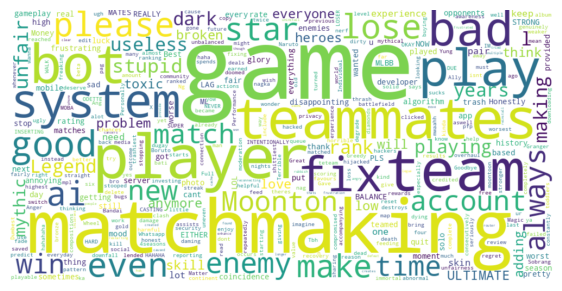

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['text'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=1000).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
import re
import string
import demoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer # Mengganti MPStemmer dengan PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# ini fungsinya untuk mengRemove HTML ya (khan,rin)
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

In [ ]:
#  menghapus Hashtag
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

In [ ]:
 #Remove Links & Email
def remove_rls(text):
    text = re.sub(r'https?://\S+', '', str(text))
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'www\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

In [ ]:
#  Remove Punctuation(ngehapus simbol simbol dan emotikon yang pake simbol ) List & Emoticon Teks
def remove_punctuation_list(text):
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text)
    text = re.sub(r'(:\(|:-\()', '', text)
    text = re.sub(r'(:v|:-v)', '', text)
    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
def remove_emoji(text):
    cleaned_text = demoji.replace(text, repl="")
    cleaned_text = re.sub(r'[^\x00-\x7F]+', '', cleaned_text)
    return cleaned_text

In [ ]:
# Inisialisasi PorterStemmer untuk Bahasa Inggris
ps = PorterStemmer()


In [ ]:
# Stopwords Bahasa Inggris
sw_english = set(stopwords.words('english')) - {'not', 'no', 'nor', 'neither'}

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in sw_english])

In [ ]:
df['rm_html'] = df['text'].apply(remove_html)
df.head(20)

,Authors,text,rm_html,rm_hashtag,lower_case,rm_url,rm_punc,stem,rm_emoji,rm_stopwords
0,Zwe Htet Paing Tun,the worst player community. and the worst deve...,the worst player community. and the worst deve...,the worst player community. and the worst deve...,the worst player community. and the worst deve...,the worst player community. and the worst deve...,the worst player community and the worst devel...,the worst player community and the worst devel...,the worst player community and the worst devel...,the worst player community and the worst devel...
1,Andrea Yare,"frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl...",frustrating and worsest game😡😡😤😠 i ve ever pla...,frustrating and worsest game😡😡😤😠 i ve ever pla...,frustrating and worsest game i ve ever played ...,frustrating and worsest game😡😡😤😠 i ve ever pla...
2,Lyka Calicoy,Because of A.I players,Because of A.I players,Because of A.I players,because of a.i players,because of a.i players,because of a i players,cause of a i players,because of a i players,because of a i players
3,April Shane Castillo,PLS STOP INSERTING BOTS IN THE MATCHMAKING,PLS STOP INSERTING BOTS IN THE MATCHMAKING,PLS STOP INSERTING BOTS IN THE MATCHMAKING,pls stop inserting bots in the matchmaking,pls stop inserting bots in the matchmaking,pls stop inserting bots in the matchmaking,pls stop inserting bots in the mematchmaking,pls stop inserting bots in the matchmaking,pls stop inserting bots in the matchmaking
4,fashionate lady,So stupid little death alot of gold earned goo...,So stupid little death alot of gold earned goo...,So stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...
5,Gerald Carel,what copy game,what copy game,what copy game,what copy game,what copy game,what copy game,what copy game,what copy game,what copy game
6,MD. Hossain,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...,don t not play this game and that is harmful f...,don t not play this game and that is harmful f...,don t not play this game and that is harmful f...,don t not play this game and that is harmful f...
7,Beauty and the Beast,"The matchmaking is so unfair, imagine playing ...","The matchmaking is so unfair, imagine playing ...","The matchmaking is so unfair, imagine playing ...","the matchmaking is so unfair, imagine playing ...","the matchmaking is so unfair, imagine playing ...",the matchmaking is so unfair imagine playing i...,the mematchmaking is so unfair imagine playing...,the matchmaking is so unfair imagine playing i...,the matchmaking is so unfair imagine playing i...
8,Hafiz,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...,the matchmaking is so bad. never balance. eith...,the matchmaking is so bad. never balance. eith...,the matchmaking is so bad never balance either...,the mematchmaking is so bad menever balance ei...,the matchmaking is so bad never balance either...,the matchmaking is so bad never balance either...
9,akim cicak,i love this game!!,i love this game!!,i love this game!!,i love this game!!,i love this game!!,i love this game,i love this game,i love this game,i love this game


In [ ]:
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html','rm_hashtag']].head(20)

,rm_html,rm_hashtag
0,the worst player community. and the worst deve...,the worst player community. and the worst deve...
1,"frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl..."
2,Because of A.I players,Because of A.I players
3,PLS STOP INSERTING BOTS IN THE MATCHMAKING,PLS STOP INSERTING BOTS IN THE MATCHMAKING
4,So stupid little death alot of gold earned goo...,So stupid little death alot of gold earned goo...
5,what copy game,what copy game
6,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...
7,"The matchmaking is so unfair, imagine playing ...","The matchmaking is so unfair, imagine playing ..."
8,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...
9,i love this game!!,i love this game!!


In [ ]:
df['lower_case'] = df['rm_hashtag'].str.lower()
df[['rm_hashtag', 'lower_case']].head(20)

,rm_hashtag,lower_case
0,the worst player community. and the worst deve...,the worst player community. and the worst deve...
1,"frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl..."
2,Because of A.I players,because of a.i players
3,PLS STOP INSERTING BOTS IN THE MATCHMAKING,pls stop inserting bots in the matchmaking
4,So stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...
5,what copy game,what copy game
6,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...
7,"The matchmaking is so unfair, imagine playing ...","the matchmaking is so unfair, imagine playing ..."
8,THE MATCHMAKING IS SO BAD. NEVER BALANCE. EITH...,the matchmaking is so bad. never balance. eith...
9,i love this game!!,i love this game!!


In [ ]:
df['rm_url'] = df['lower_case'].apply(remove_rls)
df[['lower_case','rm_url']].head(20)

,lower_case,rm_url
0,the worst player community. and the worst deve...,the worst player community. and the worst deve...
1,"frustrating, and worsest game😡😡😤😠 i've ever pl...","frustrating, and worsest game😡😡😤😠 i've ever pl..."
2,because of a.i players,because of a.i players
3,pls stop inserting bots in the matchmaking,pls stop inserting bots in the matchmaking
4,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...
5,what copy game,what copy game
6,don't not play this game and that is harmful f...,don't not play this game and that is harmful f...
7,"the matchmaking is so unfair, imagine playing ...","the matchmaking is so unfair, imagine playing ..."
8,the matchmaking is so bad. never balance. eith...,the matchmaking is so bad. never balance. eith...
9,i love this game!!,i love this game!!


In [ ]:
df['rm_punc'] = df['rm_url'].apply(remove_punctuation_list)
df[['rm_url','rm_punc']].head(20)

,rm_url,rm_punc
0,the worst player community. and the worst deve...,the worst player community and the worst devel...
1,"frustrating, and worsest game😡😡😤😠 i've ever pl...",frustrating and worsest game😡😡😤😠 i ve ever pla...
2,because of a.i players,because of a i players
3,pls stop inserting bots in the matchmaking,pls stop inserting bots in the matchmaking
4,so stupid little death alot of gold earned goo...,so stupid little death alot of gold earned goo...
5,what copy game,what copy game
6,don't not play this game and that is harmful f...,don t not play this game and that is harmful f...
7,"the matchmaking is so unfair, imagine playing ...",the matchmaking is so unfair imagine playing i...
8,the matchmaking is so bad. never balance. eith...,the matchmaking is so bad never balance either...
9,i love this game!!,i love this game


In [ ]:
df['rm_stopwords'] = df['rm_punc'].apply(lambda x: " ".join([ps.stem(word) for word in str(x).split()]) if isinstance(x, str) else '')
df[['rm_punc','rm_stopwords']].head(20)


,rm_punc,rm_stopwords
0,the worst player community and the worst devel...,the worst player commun and the worst develop ...
1,frustrating and worsest game😡😡😤😠 i ve ever pla...,frustrat and worsest game😡😡😤😠 i ve ever play e...
2,because of a i players,becaus of a i player
3,pls stop inserting bots in the matchmaking,pl stop insert bot in the matchmak
4,so stupid little death alot of gold earned goo...,so stupid littl death alot of gold earn good a...
5,what copy game,what copi game
6,don t not play this game and that is harmful f...,don t not play thi game and that is harm for u...
7,the matchmaking is so unfair imagine playing i...,the matchmak is so unfair imagin play in a bat...
8,the matchmaking is so bad never balance either...,the matchmak is so bad never balanc either my ...
9,i love this game,i love thi game


In [ ]:
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem','rm_stopwords']].head(20)

,stem,rm_stopwords
0,the worst player commun and the worst develop ...,worst player commun worst develop ever moba hi...
1,frustrat and worsest game😡😡😤😠 i ve ever play e...,frustrat worsest game😡😡😤😠 ever play enemi alwa...
2,becaus of a i player,becaus player
3,pl stop insert bot in the matchmak,pl stop insert bot matchmak
4,so stupid littl death alot of gold earn good a...,stupid littl death alot gold earn good amount ...
5,what copi game,copi game
6,don t not play thi game and that is harm for u...,not play thi game harm us reason becaus thi ga...
7,the matchmak is so unfair imagin play in a bat...,matchmak unfair imagin play battlefield rank m...
8,the matchmak is so bad never balanc either my ...,matchmak bad never balanc either team bad enem...
9,i love thi game,love thi game


In [ ]:



df['rm_punc'] = df['rm_url'].apply(remove_punctuation_list)

df['rm_stopwords'] = df['rm_punc'].apply(remove_stopwords)

df['rm_emoji'] = df['rm_stopwords'].apply(remove_emoji)

df[['rm_stopwords', 'rm_emoji']].head(20)




,rm_stopwords,rm_emoji
0,worst player community worst developer ever mo...,worst player community worst developer ever mo...
1,frustrating worsest game😡😡😤😠 ever played enemi...,frustrating worsest game ever played enemies a...
2,players,players
3,pls stop inserting bots matchmaking,pls stop inserting bots matchmaking
4,stupid little death alot gold earned good amou...,stupid little death alot gold earned good amou...
5,copy game,copy game
6,not play game harmful us reason game dirty mat...,not play game harmful us reason game dirty mat...
7,matchmaking unfair imagine playing battlefield...,matchmaking unfair imagine playing battlefield...
8,matchmaking bad never balance either team bad ...,matchmaking bad never balance either team bad ...
9,love game,love game


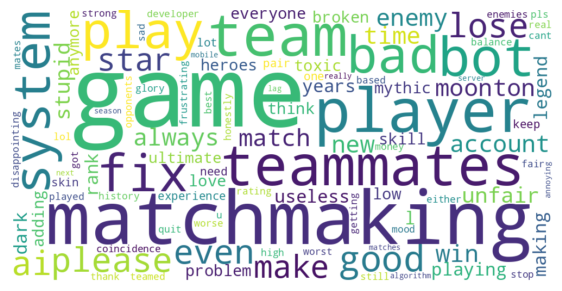

In [ ]:
text = ' '.join(df['rm_stopwords'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
df.rename(columns={'rm_stopwords': 'prepro'}, inplace=True)
df.info()

# Menyimpan hasil akhir ke file CSV (Sama persis seperti contoh dosen)
df[['Authors','text','prepro']].to_csv('mobile_legends_preprocessed.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Authors     51 non-null     object
 1   text        51 non-null     object
 2   rm_html     51 non-null     object
 3   rm_hashtag  51 non-null     object
 4   lower_case  51 non-null     object
 5   rm_url      51 non-null     object
 6   rm_punc     51 non-null     object
 7   stem        51 non-null     object
 8   rm_emoji    51 non-null     object
 9   prepro      51 non-null     object
 10  lemmatized  51 non-null     object
dtypes: object(11)
memory usage: 4.5+ KB
